# homeworksheet 2
here comes the work

In [133]:
import os
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


import the data:

In [79]:
file_name = 'data/WHO-COVID-19-global-data.csv'

df = pd.read_csv(file_name)

##### task 1
lets have a look at the data first


In [80]:
df.dtypes

Date_reported            str
Country_code             str
Country                  str
WHO_region               str
New_cases            float64
Cumulative_cases       int64
New_deaths           float64
Cumulative_deaths      int64
dtype: object

In [81]:
testdatum = df.Date_reported[1]
pd.to_datetime(testdatum)

Timestamp('2020-01-12 00:00:00')

In [82]:
df.Date_reported = pd.to_datetime(df.Date_reported)

In [83]:
df.dtypes

Date_reported        datetime64[us]
Country_code                    str
Country                         str
WHO_region                      str
New_cases                   float64
Cumulative_cases              int64
New_deaths                  float64
Cumulative_deaths             int64
dtype: object

oh super jetzt können wir nach date_reported filtern

In [84]:
pd.to_datetime('2024-01-08')


Timestamp('2024-01-08 00:00:00')

In [85]:
df_august = df[df.Date_reported<"2024-08-01"].copy()
df_august

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-05,AF,Afghanistan,EMRO,NaN,0,NaN,0
1,2020-01-12,AF,Afghanistan,EMRO,NaN,0,NaN,0
2,2020-01-19,AF,Afghanistan,EMRO,NaN,0,NaN,0
3,2020-01-26,AF,Afghanistan,EMRO,NaN,0,NaN,0
4,2020-02-02,AF,Afghanistan,EMRO,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
78387,2024-06-30,XXL,International commercial vessel,OTHER,NaN,29,NaN,0
78388,2024-07-07,XXL,International commercial vessel,OTHER,NaN,29,NaN,0
78389,2024-07-14,XXL,International commercial vessel,OTHER,NaN,29,NaN,0
78390,2024-07-21,XXL,International commercial vessel,OTHER,NaN,29,NaN,0


Choose any country given in the dataset and extract corresponding entries.

In [86]:
set(df.Country)

{'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia (Plurinational State of)',
 'Bonaire, Saint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Cura�ao',
 'Cyprus',
 'Czechia',
 "C�te d'Ivoire",
 "Democratic People's Republic of Korea",
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea

In [87]:
df_country_august = df_august[df_august.Country=="occupied Palestinian territory, including east Jerusalem"].copy()
df_country_august

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
48091,2020-01-05,PS,"occupied Palestinian territory, including east...",EMRO,NaN,0,NaN,0
48092,2020-01-12,PS,"occupied Palestinian territory, including east...",EMRO,NaN,0,NaN,0
48093,2020-01-19,PS,"occupied Palestinian territory, including east...",EMRO,NaN,0,NaN,0
48094,2020-01-26,PS,"occupied Palestinian territory, including east...",EMRO,NaN,0,NaN,0
48095,2020-02-02,PS,"occupied Palestinian territory, including east...",EMRO,NaN,0,NaN,0
...,...,...,...,...,...,...,...,...
49117,2024-06-30,PS,"occupied Palestinian territory, including east...",EMRO,NaN,703228,NaN,5708
49118,2024-07-07,PS,"occupied Palestinian territory, including east...",EMRO,NaN,703228,NaN,5708
49119,2024-07-14,PS,"occupied Palestinian territory, including east...",EMRO,NaN,703228,NaN,5708
49120,2024-07-21,PS,"occupied Palestinian territory, including east...",EMRO,NaN,703228,NaN,5708


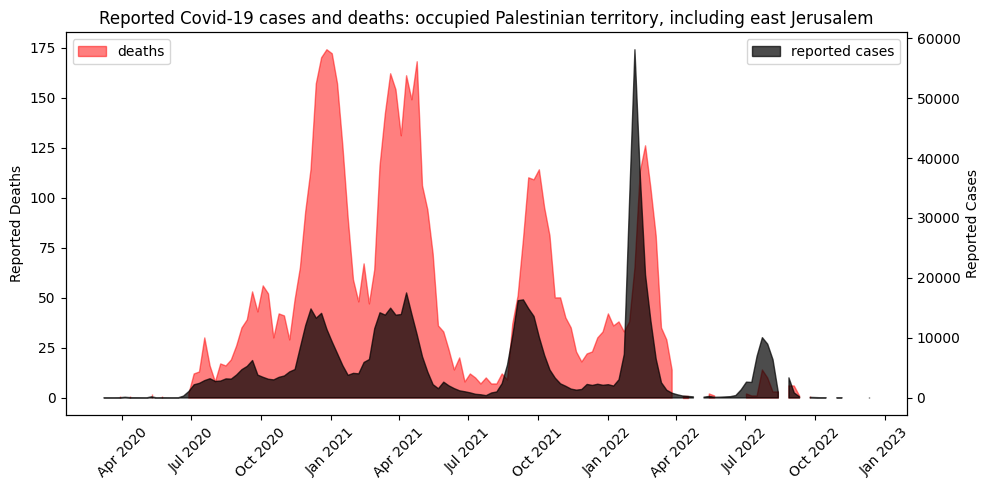

In [88]:
fig, ax = plt.subplots(figsize=(10,5))
ax2 = ax.twinx()

country = "occupied Palestinian territory, including east Jerusalem"

country_df = df[df['Country']==country].copy()

ax2.fill_between(country_df.Date_reported, 
                country_df.New_cases,
                color="black",
                alpha=0.7,
                label="reported cases")

ax.fill_between(country_df.Date_reported, 
                country_df.New_deaths,
                color="red",
                alpha=0.5,
                label="deaths")

ax2.set_ylabel("Reported Cases")
ax.set_ylabel("Reported Deaths")

ax.legend(loc='upper left')
ax2.legend()

ax.xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%b %Y'))
ax.xaxis.set_tick_params(rotation=45)

ax.set_title(f'Reported Covid-19 cases and deaths: {country}')
plt.tight_layout()

#inspired quite a lot from the example solution, whoopsie

##### Task 2: same as 1 but for cumulative cases and deaths
ok, but for denmark this time

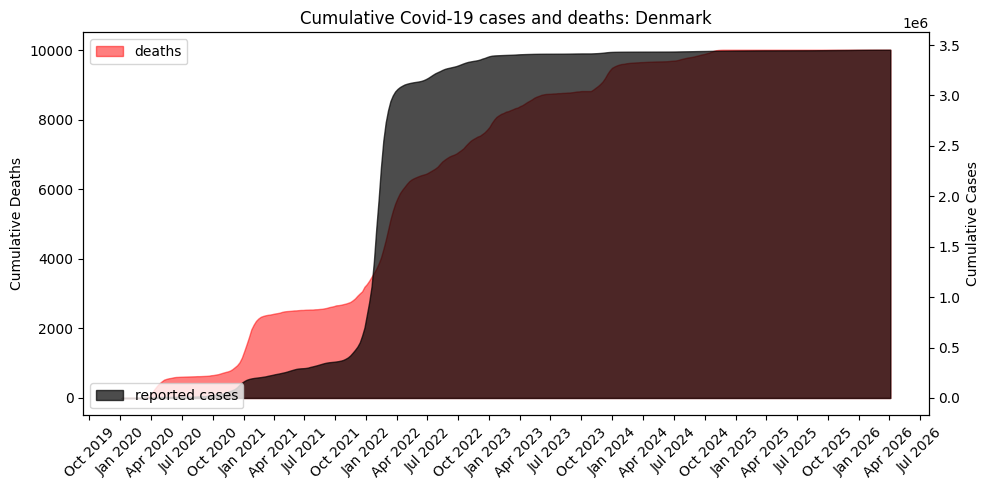

In [89]:
fig, ax = plt.subplots(figsize=(10,5))
ax2 = ax.twinx()

country = "Denmark"

country_df = df[df['Country']==country].copy()

ax2.fill_between(country_df.Date_reported, 
                country_df.Cumulative_cases,
                color="black",
                alpha=0.7,
                label="reported cases")

ax.fill_between(country_df.Date_reported, 
                country_df.Cumulative_deaths,
                color="red",
                alpha=0.5,
                label="deaths")

ax2.set_ylabel("Cumulative Cases")
ax.set_ylabel("Cumulative Deaths")

ax.legend(loc='upper left')
ax2.legend(loc='lower left')

ax.xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%b %Y'))
ax.xaxis.set_tick_params(rotation=45)

ax.set_title(f'Cumulative Covid-19 cases and deaths: {country}')
plt.tight_layout()

#inspired quite a lot from the example solution, whoopsie

##### Task 3
okaaaayyy lets go

In [139]:
WHO_regions = df.WHO_region.dropna().unique()
WHO_regions #= WHO_regions[WHO_regions != 'nan']



<StringArray>
['EMRO', 'AMRO', 'EURO', 'AFRO', 'SEARO', 'WPRO', 'OTHER']
Length: 7, dtype: str

In [128]:
df_by_region = df[['Date_reported','New_cases','WHO_region']].groupby('WHO_region').resample("W", on='Date_reported')['New_cases'].sum().to_frame()



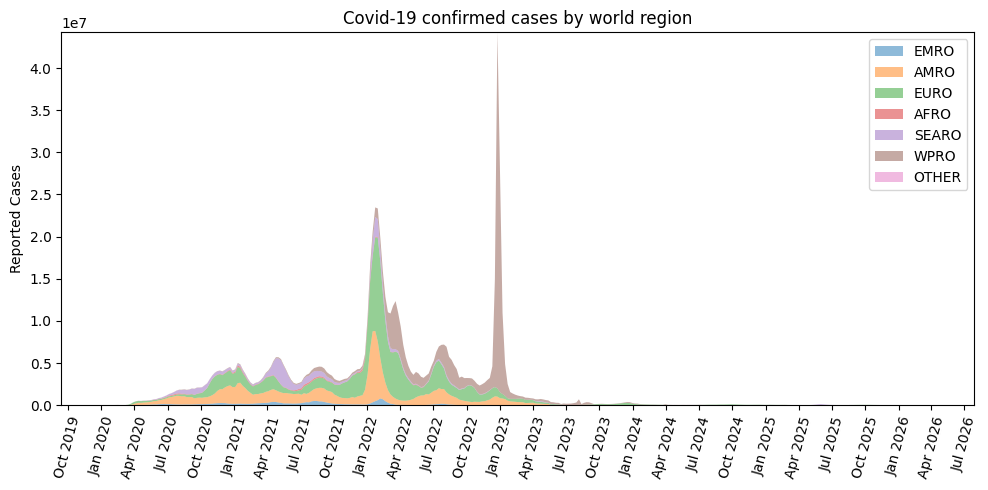

In [142]:
fig, ax = plt.subplots(figsize=(10,5))


prev = None
for region in WHO_regions[:]:
    region_data = df_by_region.xs(region,level=0)

    y = region_data['New_cases']
    
    if prev is None:
        prev = pd.Series(0, index=y.index)

    ax.fill_between(y.index, 
                    prev+y, 
                    prev,
                    alpha=0.5, 
                    label=region)
    
    prev += y

ax.set_ylabel("Reported Cases")
ax.set_ylim([0, prev.max()])

ax.xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%b %Y'))
ax.xaxis.set_tick_params(rotation=75)

ax.legend(loc='upper right')

ax.set_title('Covid-19 confirmed cases by world region')
plt.tight_layout()


bruh this was so exhausting like wtf is that python shit...